<a href="https://colab.research.google.com/github/karinaangr/machine-learning-project/blob/main/machine_learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Komputasi Machine Learning

# PENDAHULUAN

Dalam studi ini, dilakukan penerapan metode machine learning untuk menganalisis faktor-faktor yang memengaruhi harapan hidup *(life expectancy)* suatu negara menggunakan berbagai indikator kesehatan, sosial, dan ekonomi. Dataset yang digunakan memuat informasi seperti tingkat pendidikan, angka kematian, status perkembangan negara *(developed atau developing)*, konsumsi alkohol, imunisasi, BMI, serta variabel lain yang berkaitan dengan kualitas hidup masyarakat.

Pada pengerjaan ini, permasalahan dimodelkan dalam dua pendekatan, yaitu klasifikasi dan regresi. Pada klasifikasi, model digunakan untuk mengidentifikasi status suatu negara ke dalam kategori **Developed atau Developing**. Sementara pada regresi, model digunakan untuk memprediksi nilai *life expectancy* berdasarkan variabel-variabel yang tersedia.

Untuk menyelesaikan permasalahan tersebut, digunakan tiga algoritma machine learning, yaitu Support Vector Machine (SVM), k-Nearest Neighbor (k-NN), dan Random Forest. Ketiga model kemudian dibandingkan berdasarkan performa prediksi dan efisiensi komputasi menggunakan berbagai metrik evaluasi sehingga dapat diketahui model yang memberikan hasil terbaik pada dataset.

Sebelum proses pemodelan dilakukan, data melalui tahap preprocessing seperti penanganan data tidak seimbang *(imbalanced data)* menggunakan SMOTE, normalisasi atau standardisasi data, serta pembagian data latih dan data uji untuk meningkatkan kualitas hasil pemodelan.

## Tujuan

Studi ini bertujuan untuk:
* Melakukan klasifikasi status negara (Developed / Developing)

* Melakukan prediksi life expectancy menggunakan metode regresi

* Membandingkan performa model SVM, k-NN, dan Random Forest

* Menentukan model terbaik berdasarkan hasil evaluasi performa

# DESKRIPSI DATASET

Dataset yang digunakan merupakan dataset Life Expectancy yang berisi berbagai indikator kesehatan, sosial, dan ekonomi dari berbagai negara. Variabel dalam dataset meliputi status perkembangan negara (Developed/Developing), tingkat pendidikan, angka kematian, imunisasi, BMI, konsumsi alkohol, serta faktor lain yang berpotensi memengaruhi harapan hidup (life expectancy). Dataset ini digunakan sebagai dasar analisis dan pemodelan machine learning untuk klasifikasi dan prediksi.

## Memuat dataset

In [ ]:
import pandas as pd

# download the dataset
url= "https://raw.githubusercontent.com/Sudhir878786/Life-Expectancy-WHO/master/Life%20Expectancy%20Data.csv"

# read the input data
raw_data=pd.read_csv(url)
raw_data

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [ ]:
raw_data.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# PRAPEMROSESAN DATA

In [ ]:
import pandas as pd

# load data langsung dari URL publik
url = "https://raw.githubusercontent.com/Sudhir878786/Life-Expectancy-WHO/master/Life%20Expectancy%20Data.csv"
df = pd.read_csv(url)

print("  INFORMASI AWAL DATASET")
print(" ")
print(f"Dimensi         : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"Jumlah Negara   : {df['Country'].nunique()}")
print(f"Rentang Tahun   : {df['Year'].min()} – {df['Year'].max()}")
print(f"Distribusi Status:")
print(df['Status'].value_counts().to_string())

  INFORMASI AWAL DATASET
 
Dimensi         : 2938 baris × 22 kolom
Jumlah Negara   : 193
Rentang Tahun   : 2000 – 2015
Distribusi Status:
Status
Developing    2426
Developed      512


In [ ]:
kolom_lama = df.columns.tolist()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)
rename_map = {
    'percentage_expenditure':           'pct_expenditure_health',
    'underfive_deaths':                 'under5_deaths',
    'hivaids':                          'hiv_aids',
    'thinness_119_years':               'thinness_1_19y',
    'thinness_59_years':                'thinness_5_9y',
    'income_composition_of_resources':  'income_composition',
}
df = df.rename(columns=rename_map)


In [ ]:

missing_before = df.isnull().sum()
missing_pct    = (missing_before / len(df) * 100).round(2)

print(f"{'Kolom':<35} {'Missing':>8} {'%':>7}")
print("-" * 52)
for col in df.columns:
    if missing_before[col] > 0:
        print(f"  {col:<33} {missing_before[col]:>8} {missing_pct[col]:>6.2f}%")


Kolom                                Missing       %
----------------------------------------------------
  life_expectancy                         10   0.34%
  adult_mortality                         10   0.34%
  alcohol                                194   6.60%
  hepatitis_b                            553  18.82%
  bmi                                     34   1.16%
  polio                                   19   0.65%
  total_expenditure                      226   7.69%
  diphtheria                              19   0.65%
  gdp                                    448  15.25%
  population                             652  22.19%
  thinness_1_19y                          34   1.16%
  thinness_5_9y                           34   1.16%
  income_composition                     167   5.68%
  schooling                              163   5.55%


In [ ]:
kolom_numerik = df.select_dtypes(include='number').columns.drop(['year'])

for col in kolom_numerik:
    if df[col].isnull().any():
        df[col] = df.groupby('country')[col].transform(
            lambda x: x.fillna(x.median())
        )
        df[col] = df[col].fillna(df[col].median())

print(f"Total missing value setelah imputasi: {df.isnull().sum().sum()}")


Total missing value setelah imputasi: 0


In [ ]:
# tipe data & encoding
df['year'] = df['year'].astype(int)
df['status_encoded'] = df['status'].map({'Developing': 0, 'Developed': 1})
print("Enkoding 'status':  Developing=0, Developed=1")
print(df[['status','status_encoded']].drop_duplicates().to_string(index=False))


Enkoding 'status':  Developing=0, Developed=1
    status  status_encoded
Developing               0
 Developed               1


In [ ]:
import numpy as np
from scipy import stats

kolom_outlier = [
    'adult_mortality', 'alcohol', 'bmi', 'hiv_aids',
    'gdp', 'population', 'schooling', 'income_composition'
]

print(f"\n{'Kolom':<35} {'Outlier IQR':>12} {'Outlier Z>3':>12}")
print("-" * 60)

for col in kolom_outlier:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    n_iqr  = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    z      = np.abs(stats.zscore(df[col]))
    n_z    = (z > 3).sum()
    print(f"  {col:<33} {n_iqr:>12} {n_z:>12}")

# Winsorizing pada persentil 1–99
print("\nStrategi: Winsorizing pada persentil 1–99 untuk kolom skewed")
for col in ['gdp', 'population', 'hiv_aids', 'adult_mortality']:
    p1  = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col + '_winsorized'] = df[col].clip(lower=p1, upper=p99)
    print(f" '{col}' → '{col}_winsorized'  [{p1:.2f}, {p99:.2f}]")


Kolom                                Outlier IQR  Outlier Z>3
------------------------------------------------------------
  adult_mortality                             86           40
  alcohol                                      1            3
  bmi                                          0            0
  hiv_aids                                   542           69
  gdp                                        445           96
  population                                 452           24
  schooling                                   77           28
  income_composition                         130          130

Strategi: Winsorizing pada persentil 1–99 untuk kolom skewed
 'gdp' → 'gdp_winsorized'  [24.46, 62233.87]
 'population' → 'population_winsorized'  [813.87, 146938416.42]
 'hiv_aids' → 'hiv_aids_winsorized'  [0.10, 29.28]
 'adult_mortality' → 'adult_mortality_winsorized'  [4.37, 583.04]


In [ ]:
# Ensure df columns are cleaned to lowercase
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)
# The rename_map from Vg9GV2QyM_r2 needs to be applied if not already
rename_map = {
    'percentage_expenditure':           'pct_expenditure_health',
    'underfive_deaths':                 'under5_deaths',
    'hivaids':                          'hiv_aids',
    'thinness_1_19y':                   'thinness_1_19y',
    'thinness_5_9y':                    'thinness_5_9y',
    'income_composition_of_resources':  'income_composition',
}
df = df.rename(columns=rename_map)

# Re-define num_cols to ensure it reflects the current df
num_cols = df.select_dtypes(include='number').columns.drop('year').tolist()

fitur_model = df[num_cols].drop(columns=['life_expectancy', 'status_enc'], errors='ignore').columns.tolist()

corr_with_target = df[fitur_model + ['life_expectancy']].corr()['life_expectancy'].drop('life_expectancy')
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

print(f"\n{'Fitur':<35} {'Korelasi':>10}")
print("-" * 47)
for feat in corr_sorted.index:
    val  = corr_with_target[feat]
    print(f"  {feat:<33} {val:>+.4f}")


Fitur                                 Korelasi
-----------------------------------------------
  schooling                         +0.7131
  adult_mortality_winsorized        -0.6970
  adult_mortality                   -0.6964
  income_composition                +0.6887
  hiv_aids_winsorized               -0.5911
  bmi                               +0.5569
  hiv_aids                          -0.5567
  diphtheria                        +0.4840
  status_encoded                    +0.4814
  polio                             +0.4705
  thinness_1_19y                    -0.4680
  thinness_5_9y                     -0.4625
  gdp_winsorized                    +0.4495
  gdp                               +0.4315
  alcohol                           +0.4040
  pct_expenditure_health            +0.3814
  hepatitis_b                       +0.3009
  total_expenditure                 +0.2264
  under5_deaths                     -0.2227
  infant_deaths                     -0.1968
  measles               

# ANALISIS DATA

## Metode SVM

Akan dibentuk model klasifikasi dan regresi menggunakan metode SVM.

1.   Model Klasifikasi
2.   Model Regresi

In [ ]:
# Import the libraries we need to use in this lab
from __future__ import print_function
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC

<div id="dataset_analysis">
    <h2>Analisa Dataset</h2>
</div>


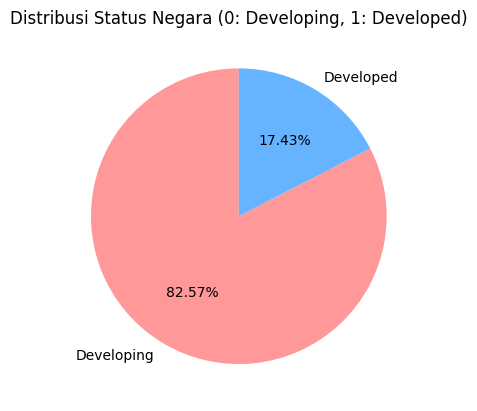

In [ ]:
# Mengambil nilai unik (sekarang isinya akan berupa angka 0 dan 1)
labels = df['status'].unique()

# Menghitung jumlah data untuk masing-masing angka
sizes = df['status'].value_counts().values

# Gambar pie chart
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=90, colors=['#ff9999','#66b3ff'])
ax.set_title('Distribusi Status Negara (0: Developing, 1: Developed)')
plt.show()

Pie chart menunjukkan bahwa sebagian besar data dalam dataset berasal dari negara dengan status Developing (82,57%), sedangkan negara Developed hanya sebesar 17,43%. Distribusi ini menunjukkan adanya ketidakseimbangan kelas, sehingga pada pemodelan klasifikasi SVM perlu digunakan penanganan seperti class_weight='balanced' agar model tidak terlalu bias terhadap kelas mayoritas.
Selain itu, untuk memastikan performa model pada kelas minoritas (Developed) tetap baik, evaluasi sebaiknya tidak hanya menggunakan akurasi, tetapi juga menggunakan metrik lain seperti:


*   Precision → seberapa banyak prediksi Developed yang benar
*  Recall → seberapa baik model mengenali seluruh negara Developed
* F1-score → kombinasi precision dan recall untuk menilai keseimbangan prediksi
* Confusion matrix → untuk melihat kesalahan prediksi antara Developing dan Developed

Dengan menggunakan metrik-metrik ini, kita dapat memantau performa model secara lebih menyeluruh dan memastikan bahwa kelas minoritas tidak diabaikan dalam pemodelan SVM.

###Model SVC

Pada tahap preprocessing data untuk klasifikasi menggunakan Support Vector Classification (SVC), dataset terlebih dahulu dibersihkan dengan menghapus kolom non-numerik yang tidak relevan Country dan Year, serta memetakan variabel target Status ke dalam dua kelas, yaitu Developing (0) dan Developed (1).

Selanjutnya dilakukan pengecekan struktur data, penghapusan nilai yang hilang, serta pembagian data menjadi dua bagian dengan perbandingan 80:20, di mana data latih digunakan untuk membangun model dan data uji untuk mengevaluasi kinerja model. Karena fitur-fitur prediktor memiliki satuan yang berbeda, maka dilakukan standarisasi menggunakan StandardScaler agar semua variabel berada pada skala yang sebanding, sehingga algoritma SVC dapat bekerja lebih optimal dalam membedakan pola antara negara berkembang dan negara maju.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/Sudhir878786/Life-Expectancy-WHO/master/Life%20Expectancy%20Data.csv"
df = pd.read_csv(url)

# Fitur: semua kecuali kolom non-numerik dan target
X = df.drop(columns=["Country", "Year", "Status"])
y = df["Status"].map({"Developing": 0, "Developed": 1})

# Hapus missing values
X = X.dropna()
y = y.loc[X.index]

# Split data dengan stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standarisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model SVM Linear
svm_linear = SVC(kernel="linear", random_state=42, class_weight='balanced')
svm_linear.fit(X_train_scaled, y_train)

# Prediksi
y_pred_linear = svm_linear.predict(X_test_scaled)

# Evaluasi
acc_linear = accuracy_score(y_test, y_pred_linear)
report_linear = classification_report(y_test, y_pred_linear, target_names=["Developing", "Developed"])

print("SVM Kernel Linear")
print("Akurasi:", acc_linear)
print("\nLaporan Klasifikasi:\n", report_linear)

# Model SVM RBF
svm_model = SVC(kernel="rbf", random_state=42, class_weight='balanced')
svm_model.fit(X_train_scaled, y_train)

# Prediksi
y_pred = svm_model.predict(X_test_scaled)

# Evaluasi
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["Developing", "Developed"])

print("SVM Kernel RBF")
print(" Akurasi:", acc)
print("\n Laporan Klasifikasi:\n", report)

SVM Kernel Linear
Akurasi: 0.9333333333333333

Laporan Klasifikasi:
               precision    recall  f1-score   support

  Developing       1.00      0.93      0.96       282
   Developed       0.69      0.98      0.81        48

    accuracy                           0.93       330
   macro avg       0.84      0.95      0.88       330
weighted avg       0.95      0.93      0.94       330

SVM Kernel RBF
 Akurasi: 0.9454545454545454

 Laporan Klasifikasi:
               precision    recall  f1-score   support

  Developing       0.99      0.94      0.97       282
   Developed       0.74      0.96      0.84        48

    accuracy                           0.95       330
   macro avg       0.87      0.95      0.90       330
weighted avg       0.96      0.95      0.95       330



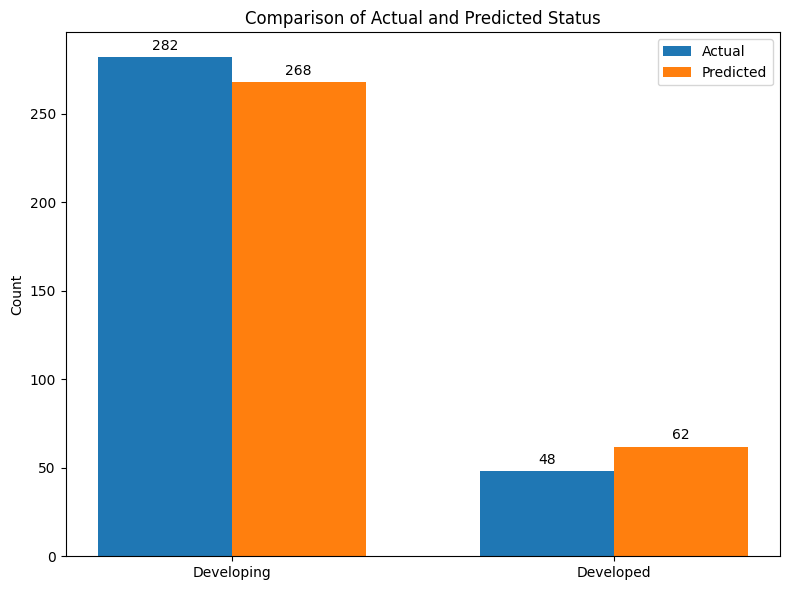

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a bar chart to compare predicted vs actual status
labels = ['Developing', 'Developed']
x = np.arange(len(labels))

# Count occurrences of each status in actual and predicted data
actual_counts = y_test.value_counts().sort_index()
predicted_counts = pd.Series(y_pred).value_counts().sort_index()

# Handle cases where a class might be missing in predictions
actual_counts = actual_counts.reindex([0, 1], fill_value=0)
predicted_counts = predicted_counts.reindex([0, 1], fill_value=0)


width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, actual_counts, width, label='Actual')
rects2 = ax.bar(x + width/2, predicted_counts, width, label='Predicted')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Count')
ax.set_title('Comparison of Actual and Predicted Status')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.show()

Grafik tersebut menunjukkan bahwa model SVM yang menggunakan class_weight='balanced' memprediksi kelas Developing sebanyak 268 negara dan Developed sebanyak 62 negara, sehingga distribusi prediksi lebih seimbang dibanding distribusi aktual. Penggunaan balanced ini meningkatkan representasi kelas minoritas (Developed), sehingga recall untuk Developed meningkat, walaupun jumlah prediksi untuk Developing sedikit berkurang.

###Model SVR

Pada tahap preprocessing data, dilakukan pembersihan nama kolom agar
lebih rapi, pengecekan struktur data, serta pemilihan variabel yang relevan untuk
penelitian, yaitu Adult Mortality, BMI, Schooling, Income composition of resour-
ces, dan GDP sebagai prediktor, serta Life expectancy sebagai variabel target. Data
kemudian dibagi menjadi data latih dan data uji dengan perbandingan 80:20, di-
ikuti proses standarisasi menggunakan StandardScaler untuk menyamakan skala
variabel. Standarisasi ini penting karena perbedaan satuan antar variabel dapat me-
mengaruhi kinerja algoritma Support Vector Regression (SVR).

In [ ]:

# Load dataset
url = "https://raw.githubusercontent.com/Sudhir878786/Life-Expectancy-WHO/master/Life%20Expectancy%20Data.csv"
df = pd.read_csv(url)

print(df.head())
print(df.info())

       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   ...  \
0             62     0.01               71.279624         65.0      1154  ...   
1             64     0.01               73.523582         62.0       492  ...   
2             66     0.01               73.219243         64.0       430  ...   
3             69     0.01               78.184215         67.0      2787  ...   
4             71     0.01                7.097109         68.0      3013  ...   

   Polio  Total expenditure  Diphtheria    HIV/AIDS         GDP  Population  \
0    6.

In [ ]:
print(df.columns)
df.columns.str.strip()

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')


Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset again to ensure current state for SVR block (as df was reloaded in previous cell)
url = "https://raw.githubusercontent.com/Sudhir878786/Life-Expectancy-WHO/master/Life%20Expectancy%20Data.csv"
df = pd.read_csv(url)

# Clean column names (copied from Vg9GV2QyM_r2)
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)
rename_map = {
    'percentage_expenditure':           'pct_expenditure_health',
    'underfive_deaths':                 'under5_deaths',
    'hivaids':                          'hiv_aids',
    'thinness_119_years':               'thinness_1_19y',
    'thinness_59_years':                'thinness_5_9y',
    'income_composition_of_resources':  'income_composition',
}
df = df.rename(columns=rename_map)

features = ["adult_mortality", "bmi", "schooling", "income_composition", "gdp"]

X = df[features]
y = df["life_expectancy"]

# Hapus missing values hanya di kolom yang dipakai
X = X.dropna()
y = y.loc[X.index]

# Split Train-Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model SVR
svr = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_train_scaled, y_train)

# Evaluasi
y_pred = svr.predict(X_test_scaled)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))


MSE: 9.529688928243855
R^2: 0.8994353473961703


## Metode k-NN

Akan dibentuk model klasifikasi dan regresi menggunakan metode k-NN.

1.   Model klasifikasi untuk memprediksi status negara
2.   Model regresi untuk memprediksi angka harapan hidup



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       StratifiedKFold, KFold, GridSearchCV,
                                       learning_curve)
from sklearn.neighbors        import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing    import MinMaxScaler
from sklearn.metrics          import (accuracy_score, f1_score, roc_auc_score,
                                       roc_curve, precision_recall_curve,
                                       confusion_matrix, ConfusionMatrixDisplay,
                                       classification_report,
                                       mean_absolute_error, mean_squared_error,
                                       r2_score)
from sklearn.inspection       import permutation_importance
from sklearn.decomposition    import PCA
from imblearn.over_sampling   import SMOTE

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
df = raw_data.copy()
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(r'\s+','_',regex=True)
              .str.replace(r'[^a-z0-9_]','',regex=True))

rename = {
    'percentage_expenditure'        : 'pct_health_exp',
    'underfive_deaths'              : 'under5_deaths',
    'hivaids'                       : 'hiv_aids',
    'thinness_119_years'            : 'thinness_1_19y',
    'thinness_59_years'             : 'thinness_5_9y',
    'income_composition_of_resources':'income_composition',
}
df = df.rename(columns=rename)

print(f"  Dimensi awal   : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"  Rentang tahun  : {df.year.min()} – {df.year.max()}")
print(f"  Jumlah negara  : {df.country.nunique()}")
print(f"  Target range  : {df['life_expectancy'].min():.1f} – {df['life_expectancy'].max():.1f} tahun")


  Dimensi awal   : 2938 baris × 22 kolom
  Rentang tahun  : 2000 – 2015
  Jumlah negara  : 193
  Target range  : 36.3 – 89.0 tahun


In [ ]:
# menangani data dengan missing value
# mengisi nilai median dari data yang lain
num_cols = df.select_dtypes(include='number').columns.drop('year')
for col in num_cols:
    if df[col].isnull().any():
        df[col] = df.groupby('country')[col].transform(
            lambda x: x.fillna(x.median()))
        df[col] = df[col].fillna(df[col].median())

print(f"  Missing tersisa: {df.isnull().sum().sum()}")

  Missing tersisa: 0


### 1. Model Klasifikasi dengan k-NN

In [ ]:
# encoding target klasifikasi (mengubah data kategorikal menjadi angka 0 dan 1)

df['status_enc'] = df['status'].map({'Developing':0,'Developed':1})

In [ ]:
# fitur yang akar digunakan

FITUR_CLF = [c for c in num_cols
             if c not in ['life_expectancy','status_enc']]
print(f"\n  Fitur klasifikasi : {len(FITUR_CLF)} fitur")


  Fitur klasifikasi : 18 fitur


In [ ]:
X_clf = df[FITUR_CLF]
y_clf = df['status_enc']

KeyError: 'status_enc'

In [ ]:
# normalisasi data (scaling)

scaler_clf = MinMaxScaler()

X_clf_sc = pd.DataFrame(scaler_clf.fit_transform(X_clf), columns=FITUR_CLF)

In [ ]:
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_clf_sc, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

In [ ]:
# penyeimbangan data (karena jumlah negara developing lebih banyak) dengan Synthetic Minority Over-sampling Technique (SMOTE)
# mengambil 2 titik data negara developed yang berbeda, menarik garis lurus, kemudian menciptapak titik data baru

smote = SMOTE(random_state=42, k_neighbors=5)
Xc_tr_sm, yc_tr_sm = smote.fit_resample(Xc_tr, yc_tr)

print(f"  Train: {len(Xc_tr)} → setelah SMOTE: {len(Xc_tr_sm)}")
print(f"  Test : {len(Xc_te)}")
print(f"  Rasio imbalance awal: "
      f"{(yc_tr==0).sum()}:{ (yc_tr==1).sum()} → "
      f"setelah SMOTE: {(yc_tr_sm==0).sum()}:{(yc_tr_sm==1).sum()}")

In [ ]:
# hyperparameter tuning

k_range = range(1, 55)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf  = KFold(n_splits=5,           shuffle=True, random_state=42)

# menghitung F1 & AUC
clf_f1  = []; clf_auc = []
for k in k_range:
    m = KNeighborsClassifier(n_neighbors=k, metric='manhattan',
                             weights='distance', n_jobs=-1)
    clf_f1.append( cross_val_score(m, Xc_tr_sm, yc_tr_sm, cv=skf,
                                   scoring='f1').mean())
    clf_auc.append(cross_val_score(m, Xc_tr_sm, yc_tr_sm, cv=skf,
                                   scoring='roc_auc').mean())

NameError: name 'StratifiedKFold' is not defined

In [ ]:
# diperoleh nilai k terbaik

best_k_clf = list(k_range)[np.argmax(clf_f1)]

In [ ]:
print(f"  Klasifikasi — K optimal (F1 max)   : K = {best_k_clf}"
      f"  (F1={max(clf_f1):.4f}, AUC={clf_auc[best_k_clf-1]:.4f})")

In [ ]:
ks = lambda k: [max(1,k-4), max(1,k-2), k, k+2, k+4]

grd_clf = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    {'n_neighbors':ks(best_k_clf),
     'weights':['uniform','distance'],
     'metric':['euclidean','manhattan']},
    cv=skf, scoring='f1', n_jobs=-1)
grd_clf.fit(Xc_tr_sm, yc_tr_sm)
bp_clf = grd_clf.best_params_
print(f"  Klasifikasi best params : {bp_clf}")

In [ ]:
knn_clf = KNeighborsClassifier(**bp_clf, n_jobs=-1)
knn_clf.fit(Xc_tr_sm, yc_tr_sm)
yc_pred  = knn_clf.predict(Xc_te)
yc_prob  = knn_clf.predict_proba(Xc_te)[:,1]

acc  = accuracy_score(yc_te, yc_pred)
f1   = f1_score(yc_te, yc_pred)
auc  = roc_auc_score(yc_te, yc_prob)
cm   = confusion_matrix(yc_te, yc_pred)
tn,fp,fn,tp = cm.ravel()
sens = tp/(tp+fn)
spec = tn/(tn+fp)

print(f" KLASIFIKASI \n")
print(f"  K={bp_clf['n_neighbors']}, metric={bp_clf['metric']}, weights={bp_clf['weights']}")
print(f"  Accuracy    : {acc*100:.2f}%")
print(f"  F1-Score    : {f1:.4f}")
print(f"  AUC-ROC     : {auc:.4f}")
print(f"  Sensitivity : {sens*100:.2f}%   (recall Developed)")
print(f"  Specificity : {spec*100:.2f}%   (recall Developing)")
print(f"  Confusion   : TN={tn}  FP={fp}  FN={fn}  TP={tp}")

print()
print(classification_report(yc_te, yc_pred,
      target_names=['Developing','Developed']))

In [ ]:
# contoh

rng = np.random.RandomState(7) # ambil data random

idx_c = rng.choice(len(Xc_te), 8, replace=False)
pred_c = knn_clf.predict(Xc_te.iloc[idx_c])
prob_c = knn_clf.predict_proba(Xc_te.iloc[idx_c])[:,1]
actual_c = yc_te.iloc[idx_c].values
country_c = df.loc[X_clf_sc.iloc[Xc_te.index[idx_c]].index,'country'].values

print(f"\n  {'Negara':<28} {'Aktual':<14} {'Prediksi':<14} {'Prob Dev':>8}  Kesesuaian")
print("  " + "─"*68)
lmap = {0:'Developing', 1:'Developed'}
for i in range(8):
    ok = "Sesuai" if actual_c[i]==pred_c[i] else "Tidak Sesuai"
    print(f"  {country_c[i]:<28} {lmap[actual_c[i]]:<14} {lmap[pred_c[i]]:<14}"
          f" {prob_c[i]:>8.3f}  {ok}")

### 2. Model Regresi dengan k-NN

In [ ]:
# seleksi 5 fitur dengan korelasi tertinggi

corr_abs = (df[num_cols].corr()['life_expectancy']
              .drop('life_expectancy').abs()
              .sort_values(ascending=False))

TOP5 = corr_abs.head(5).index.tolist()
print(f"\n  Top 5 fitur korelasi tertinggi dengan life_expectancy:")
for i,f in enumerate(TOP5,1):
    v = df[TOP5+['life_expectancy']].corr()['life_expectancy'][f]
    print(f"    {i}. {f:<38}  r = {v:+.4f}")


In [ ]:
# memilih fitur dan target

X_reg = df[TOP5]
y_reg = df['life_expectancy']

In [ ]:
# normalisasi

scaler_reg = MinMaxScaler()

X_reg_sc = pd.DataFrame(scaler_reg.fit_transform(X_reg), columns=TOP5)

In [ ]:
# splitting data train dan testing

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X_reg_sc, y_reg, test_size=0.2, random_state=42)

print(f" Train: {len(Xr_tr)}   Test: {len(Xr_te)}")

In [ ]:
# pencarian nilai k

k_range = range(1, 55)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf  = KFold(n_splits=5,           shuffle=True, random_state=42)

In [ ]:
# hyperparameter tuning

reg_rmse = []; reg_r2 = []
for k in k_range:
    m = KNeighborsRegressor(n_neighbors=k, metric='manhattan',
                            weights='distance', n_jobs=-1)
    reg_rmse.append(np.sqrt(-cross_val_score(m, Xr_tr, yr_tr, cv=kf,
                                   scoring='neg_mean_squared_error').mean()))
    reg_r2.append(  cross_val_score(m, Xr_tr, yr_tr, cv=kf,
                                   scoring='r2').mean())

best_k_reg = list(k_range)[np.argmin(reg_rmse)]

print(f"  Regresi     — K optimal (RMSE min) : K = {best_k_reg}"
      f"  (RMSE={min(reg_rmse):.4f}, R²={reg_r2[best_k_reg-1]:.4f})")

In [ ]:
ks = lambda k: [max(1,k-4), max(1,k-2), k, k+2, k+4]
grd_reg = GridSearchCV(
    KNeighborsRegressor(n_jobs=-1),
    {'n_neighbors':ks(best_k_reg),
     'weights':['uniform','distance'],
     'metric':['euclidean','manhattan']},
    cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
grd_reg.fit(Xr_tr, yr_tr)
bp_reg = grd_reg.best_params_

print(f"  Regresi     best params : {bp_reg}")


In [ ]:
# evaluasi model

knn_reg = KNeighborsRegressor(**bp_reg, n_jobs=-1)
knn_reg.fit(Xr_tr, yr_tr)
yr_pred = knn_reg.predict(Xr_te)

mae  = mean_absolute_error(yr_te, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_te, yr_pred))
r2   = r2_score(yr_te, yr_pred)
mape = np.mean(np.abs((yr_te - yr_pred)/yr_te))*100

print(f" REGRESI \n")
print(f"    K={bp_reg['n_neighbors']}, metric={bp_reg['metric']}, weights={bp_reg['weights']}")
print(f"    Fitur : {len(TOP5)} (top 5 korelasi)")
print(f"    MAE   : {mae:.4f} tahun")
print(f"    RMSE  : {rmse:.4f} tahun")
print(f"    R²    : {r2:.4f}  ({r2*100:.1f}% variansi dijelaskan)")
print(f"    MAPE  : {mape:.2f}%")




In [ ]:
# contoh dengan data random

idx_r = rng.choice(len(Xr_te), 8, replace=False)
pred_r = knn_reg.predict(Xr_te.iloc[idx_r])
actual_r = yr_te.iloc[idx_r].values
country_r = df.loc[X_reg_sc.iloc[Xr_te.index[idx_r]].index,'country'].values

print(f"\n  {'Negara':<28} {'Aktual (th)':>11} {'Prediksi (th)':>13} {'Selisih':>9}")
print("  " + "─"*64)
for i in range(8):
    print(f"  {country_r[i]:<28} {actual_r[i]:>11.1f} {pred_r[i]:>13.1f}"
          f" {pred_r[i]-actual_r[i]:>+9.1f}")


## Metode Random Forest

###Model Klasifikasi dengan Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Melatih Model Awal Random Forest
print("EVALUASI MODEL AWAL RANDOM FOREST")
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(Xc_tr_sm, yc_tr_sm)

In [ ]:
#Prediksi model awal
yc_pred_rf_def = rf_default.predict(Xc_te)

# Menampilkan performa awal
print(f"Accuracy (Default) : {accuracy_score(yc_te, yc_pred_rf_def)*100:.2f}%")
print(f"F1-Score (Default) : {f1_score(yc_te, yc_pred_rf_def):.4f}")

In [ ]:
#Mencari Kombinasi Parameter Terbaik Menggunakan GridSearchCV
print("MENCARI PARAMETER TERBAIK DENGAN GRID SEARCH CV")
max_depths = range(3, 10, 2)
n_estimators_list = range(10, 101, 10)
parameters = {'max_depth': max_depths, 'n_estimators': n_estimators_list}

grd_rf = GridSearchCV(RandomForestClassifier(random_state=42), parameters, cv=skf, scoring='f1', n_jobs=-1)
grd_rf.fit(Xc_tr_sm, yc_tr_sm)

bp_rf = grd_rf.best_params_
print(f"  Random Forest best params : {bp_rf}")

#Melatih dan Mengevaluasi Model dengan Parameter Terbaik
rf_final = RandomForestClassifier(**bp_rf, random_state=42)
rf_final.fit(Xc_tr_sm, yc_tr_sm)

In [ ]:
# Prediksi Akhir
yc_pred_rf = rf_final.predict(Xc_te)
yc_prob_rf = rf_final.predict_proba(Xc_te)[:, 1]

In [ ]:
# Menghitung Metrik Evaluasi
acc_rf  = accuracy_score(yc_te, yc_pred_rf)
f1_rf   = f1_score(yc_te, yc_pred_rf)
auc_rf  = roc_auc_score(yc_te, yc_prob_rf)
cm_rf   = confusion_matrix(yc_te, yc_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
sens_rf = tp_rf / (tp_rf + fn_rf)
spec_rf = tn_rf / (tn_rf + fp_rf)

print(f"KLASIFIKASI RANDOM FOREST OPTIMAL")
print(f"  max_depth={bp_rf['max_depth']}, n_estimators={bp_rf['n_estimators']}")
print(f"  Accuracy    : {acc_rf*100:.2f}%")
print(f"  F1-Score    : {f1_rf:.4f}")
print(f"  AUC-ROC     : {auc_rf:.4f}")
print(f"  Sensitivity : {sens_rf*100:.2f}%   (recall Developed)")
print(f"  Specificity : {spec_rf*100:.2f}%   (recall Developing)")
print(f"  Confusion   : TN={tn_rf}  FP={fp_rf}  FN={fn_rf}  TP={tp_rf}")

print("\nHasil Klasifikasi Akhir Random Forest:")
print(classification_report(yc_te, yc_pred_rf, target_names=['Developing', 'Developed']))


In [ ]:
#Visualisasi Random Forest
importances = rf_final.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Fitur yang Paling Mempengaruhi Status Negara (Random Forest)")
sns.barplot(x=importances[indices], y=X_clf.columns[indices], palette="viridis")
plt.xlabel("Skor Kepentingan (Importance Score)")
plt.ylabel("Nama Fitur")
plt.tight_layout()
plt.show()


In [ ]:
#Tabel Prediksi Acak
print(f"\n  {'Negara':<28} {'Aktual':<14} {'Prediksi RF':<14} {'Prob Dev':>8}   ✓/✗")
lmap = {0: 'Developing', 1: 'Developed'}
for i in range(8):
    idx_real = idx_c[i]
    ok = "✓" if actual_c[i] == yc_pred_rf[idx_real] else "✗"
    print(f"  {country_c[i]:<28} {lmap[actual_c[i]]:<14} {lmap[yc_pred_rf[idx_real]]:<14}"
          f" {yc_prob_rf[idx_real]:>8.3f}   {ok}")

###Model Regresi dengan Random Forest

In [ ]:

num_cols = (
    df
    .select_dtypes(include='number')
    .columns
)

corr_abs = (
    df[num_cols]
    .corr()['life_expectancy']
    .drop('life_expectancy')
    .abs()
    .sort_values(
        ascending=False
    )
)

TOP7 = (
    corr_abs[
        corr_abs > 0.5
    ]
    .head(7)
    .index
    .tolist()
)

print("Top 7 fitur:")

for i, f in enumerate(TOP7, 1):

    nilai = (
        df[num_cols]
        .corr()
        ['life_expectancy']
        [f]
    )

    print(
        f"{i}. {f:<35} r={nilai:+.4f}"
    )

In [ ]:

X_rf = df[
    TOP7
]

y_rf = df[
    'life_expectancy'
]

print(
    "Ukuran fitur:",
    X_rf.shape
)

In [ ]:
data_rf = (
    pd.concat(
        [
            X_rf,
            y_rf
        ],
        axis=1
    )
    .dropna()
)

X_rf = (
    data_rf[
        TOP7
    ]
)

y_rf = (
    data_rf[
        'life_expectancy'
    ]
)

print(
    "Jumlah data:",
    len(data_rf)
)

In [ ]:
from sklearn.model_selection import (
    train_test_split
)

Xr_tr, Xr_te, yr_tr, yr_te = (
    train_test_split(
        X_rf,
        y_rf,
        test_size=0.2,
        random_state=42
    )
)

print(
    "Train:",
    Xr_tr.shape
)

print(
    "Test :",
    Xr_te.shape
)

In [ ]:
from sklearn.ensemble import (
    RandomForestRegressor
)

rf = (
    RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    )
)

rf.fit(
    Xr_tr,
    yr_tr
)

print(
    "Training selesai"
)

In [ ]:
yr_pred = rf.predict(
    Xr_te
)

prediksi_awal = pd.DataFrame({
    "No": range(1, 6),
    "Prediksi Life Expectancy": np.round(
        yr_pred[:5],
        2
    )
})


In [ ]:
# ==================================
# EVALUASI
# ==================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np


mae = (
    mean_absolute_error(
        yr_te,
        yr_pred
    )
)

rmse = np.sqrt(
    mean_squared_error(
        yr_te,
        yr_pred
    )
)

r2 = (
    r2_score(
        yr_te,
        yr_pred
    )
)

mape = (
    np.mean(
        np.abs(
            (
                yr_te.values-
                yr_pred
            )
            /
            yr_te.values
        )
    )
)*100


print(
"\nMODEL RANDOM FOREST"
)

print(
f"Fitur : {len(TOP7)}"
)

print(
f"MAE   : {mae:.4f}"
)

print(
f"RMSE  : {rmse:.4f}"
)

print(
f"R²    : {r2:.4f}"
)

print(
f"MAPE  : {mape:.2f}%"
)

In [ ]:
yr_pred = rf.predict(
    Xr_te
)

preview = pd.DataFrame({

    "Negara":
    df.loc[
        Xr_te.index,
        "country"
    ].values,

    "Aktual (th)":
    np.round(
        yr_te.values,
        1
    ),

    "Prediksi (th)":
    np.round(
        yr_pred,
        1
    )

})


preview["Selisih"] = np.round(
    preview["Prediksi (th)"]
    -
    preview["Aktual (th)"],
    1
)


print(
preview
.sample(
8,
random_state=42
)
.to_string(
index=False
)
)

# PERBANDINGAN MODEL
Perbandingan performa tiga metode machine learning yang digunakan:
**SVM**, **k-NN**, dan **Random Forest**. \
Masing-masing model klasifikasi (memprediksi status negara: Developing/Developed) dan regresi (memprediksi life expectancy).

## Setup & Load ulang data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing    import StandardScaler, MinMaxScaler
from sklearn.metrics          import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.svm              import SVC, SVR
from sklearn.neighbors        import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble         import RandomForestClassifier, RandomForestRegressor
from imblearn.over_sampling   import SMOTE

plt.style.use('seaborn-v0_8-whitegrid')

# Load dataset
url = "https://raw.githubusercontent.com/Sudhir878786/Life-Expectancy-WHO/master/Life%20Expectancy%20Data.csv"
df_raw = pd.read_csv(url)

df = df_raw.copy()
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)
rename_map = {
    'percentage_expenditure'         : 'pct_health_exp',
    'underfive_deaths'               : 'under5_deaths',
    'hivaids'                        : 'hiv_aids',
    'thinness_119_years'             : 'thinness_1_19y',
    'thinness_59_years'              : 'thinness_5_9y',
    'income_composition_of_resources': 'income_composition',
}
df = df.rename(columns=rename_map)

# Missing value
num_cols = df.select_dtypes(include='number').columns.drop('year')
for col in num_cols:
    if df[col].isnull().any():
        df[col] = df.groupby('country')[col].transform(
            lambda x: x.fillna(x.median()))
        df[col] = df[col].fillna(df[col].median())

# Encoding target klasifikasi
df['status_enc'] = df['status'].map({'Developing': 0, 'Developed': 1})

print(f"Dataset siap: {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"Missing values tersisa: {df.isnull().sum().sum()}")

## Persiapan Data

Agar perbandingan adil, ketiga metode menggunakan **split data yang sama persis** (`random_state=42`).

In [ ]:
# KLASIFIKASI
FITUR_CLF = [c for c in num_cols if c not in ['life_expectancy', 'status_enc']]

X_clf = df[FITUR_CLF]
y_clf = df['status_enc']

# Scaler untuk SVM (StandardScaler) dan kNN (MinMaxScaler)
scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

Xc_tr_std = scaler_std.fit_transform(Xc_tr)   # untuk SVM
Xc_te_std = scaler_std.transform(Xc_te)

Xc_tr_mm  = scaler_mm.fit_transform(Xc_tr)    # untuk kNN
Xc_te_mm  = scaler_mm.transform(Xc_te)

# SMOTE untuk mengatasi imbalanced class
smote = SMOTE(random_state=42, k_neighbors=5)
Xc_tr_std_sm, yc_tr_sm = smote.fit_resample(Xc_tr_std, yc_tr)       # SVM
Xc_tr_mm_sm,  yc_tr_sm2 = smote.fit_resample(Xc_tr_mm,  yc_tr)      # kNN
Xc_tr_rf_sm, yc_tr_rf_sm = smote.fit_resample(Xc_tr, yc_tr)         # RF

print(f"[Klasifikasi] Train: {len(Xc_tr)} | Setelah SMOTE: {len(Xc_tr_std_sm)} | Test: {len(Xc_te)}")

# REGRESI
# Fitur top-5 korelasi tertinggi dengan life_expectancy
corr_abs = (df[num_cols].corr()['life_expectancy']
              .drop('life_expectancy').abs()
              .sort_values(ascending=False))
TOP5 = corr_abs.head(5).index.tolist()

print(f"\n[Regresi] Fitur top-5: {TOP5}")

X_reg = df[TOP5]
y_reg = df['life_expectancy']

scaler_reg_std = StandardScaler()
scaler_reg_mm  = MinMaxScaler()

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

Xr_tr_std = scaler_reg_std.fit_transform(Xr_tr)  # untuk SVM
Xr_te_std = scaler_reg_std.transform(Xr_te)

Xr_tr_mm  = scaler_reg_mm.fit_transform(Xr_tr)   # untuk kNN
Xr_te_mm  = scaler_reg_mm.transform(Xr_te)

print(f"[Regresi]  Train: {len(Xr_tr)} | Test: {len(Xr_te)}")

## Train semua model

* SVM (Support Vector Machine)

In [ ]:
# SVM KLASIFIKASI
start = time.time()
svc = SVC(kernel='rbf', random_state=42, class_weight='balanced', probability=True)

svc.fit(Xc_tr_std_sm, yc_tr_sm)

yc_pred_svm  = svc.predict(Xc_te_std)
yc_prob_svm  = svc.predict_proba(Xc_te_std)[:, 1]
waktu_svm_clf = time.time() - start

# SVM REGRESI
start = time.time()
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)

svr.fit(Xr_tr_std, yr_tr)
yr_pred_svm = svr.predict(Xr_te_std)
waktu_svm_reg = time.time() - start

print("✓ SVM selesai dilatih")

* k-NN (k-Nearest Neighbors)

In [ ]:
# kNN KLASIFIKASI
start = time.time()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf  = KFold(n_splits=5,           shuffle=True, random_state=42)

# K optimal
clf_f1 = []
for k in range(1, 31):
    m = KNeighborsClassifier(n_neighbors=k, metric='manhattan', weights='distance', n_jobs=-1)
    clf_f1.append(cross_val_score(m, Xc_tr_mm_sm, yc_tr_sm2, cv=skf, scoring='f1').mean())
best_k_clf = np.argmax(clf_f1) + 1

ks_clf = [max(1, best_k_clf-2), best_k_clf, best_k_clf+2]
grd_clf = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    {'n_neighbors': ks_clf, 'weights': ['uniform','distance'], 'metric': ['euclidean','manhattan']},
    cv=skf, scoring='f1', n_jobs=-1)
grd_clf.fit(Xc_tr_mm_sm, yc_tr_sm2)
bp_clf = grd_clf.best_params_

knn_clf.fit(Xc_tr_mm_sm, yc_tr_sm2)

knn_clf = KNeighborsClassifier(**bp_clf, n_jobs=-1)
knn_clf.fit(Xc_tr_mm_sm, yc_tr_sm2)
yc_pred_knn = knn_clf.predict(Xc_te_mm)
yc_prob_knn = knn_clf.predict_proba(Xc_te_mm)[:, 1]
waktu_knn_clf = time.time() - start

# kNN REGRESI
start = time.time()
reg_rmse = []
for k in range(1, 31):
    m = KNeighborsRegressor(n_neighbors=k, metric='manhattan', weights='distance', n_jobs=-1)
    reg_rmse.append(np.sqrt(-cross_val_score(m, Xr_tr_mm, yr_tr, cv=kf,
                                              scoring='neg_mean_squared_error').mean()))
best_k_reg = np.argmin(reg_rmse) + 1

ks_reg = [max(1, best_k_reg-2), best_k_reg, best_k_reg+2]
grd_reg = GridSearchCV(
    KNeighborsRegressor(n_jobs=-1),
    {'n_neighbors': ks_reg, 'weights': ['uniform','distance'], 'metric': ['euclidean','manhattan']},
    cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
grd_reg.fit(Xr_tr_mm, yr_tr)
bp_reg = grd_reg.best_params_

knn_reg.fit(Xr_tr_mm, yr_tr)

knn_reg = KNeighborsRegressor(**bp_reg, n_jobs=-1)
knn_reg.fit(Xr_tr_mm, yr_tr)
yr_pred_knn = knn_reg.predict(Xr_te_mm)
waktu_knn_reg = time.time() - start

print(f"✓ k-NN selesai dilatih | best K klasifikasi: {bp_clf['n_neighbors']} | best K regresi: {bp_reg['n_neighbors']}")

* RF (Random Forest)

In [ ]:
# RANDOM FOREST KLASIFIKASI
start = time.time()
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced',  # menangani imbalanced class
    n_jobs=-1
)
rf_clf.fit(Xc_tr_rf_sm, yc_tr_rf_sm)
yc_pred_rf = rf_clf.predict(Xc_te)
yc_prob_rf = rf_clf.predict_proba(Xc_te)[:, 1]
waktu_rf_clf = time.time() - start

# RANDOM FOREST REGRESI
start = time.time()
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(Xr_tr, yr_tr)
yr_pred_rf = rf_reg.predict(Xr_te)
waktu_rf_reg = time.time() - start

print("✓ Random Forest selesai dilatih")

## Metrik Evaluasi

In [ ]:
# Helper function
def eval_klasifikasi(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Accuracy'    : accuracy_score(y_true, y_pred),
        'Precision'   : precision_score(y_true, y_pred, zero_division=0),
        'Recall'      : recall_score(y_true, y_pred, zero_division=0),
        'F1-Score'    : f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC'     : roc_auc_score(y_true, y_prob),
        'Sensitivity' : tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Specificity' : tn / (tn + fp) if (tn + fp) > 0 else 0,
    }

def eval_regresi(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE (%)': mape}

# Metrik
results_clf = {
    'SVM'           : eval_klasifikasi(yc_te, yc_pred_svm, yc_prob_svm),
    'k-NN'          : eval_klasifikasi(yc_te, yc_pred_knn, yc_prob_knn),
    'Random Forest' : eval_klasifikasi(yc_te, yc_pred_rf,  yc_prob_rf),
}

results_reg = {
    'SVM'           : eval_regresi(yr_te, yr_pred_svm),
    'k-NN'          : eval_regresi(yr_te, yr_pred_knn),
    'Random Forest' : eval_regresi(yr_te, yr_pred_rf),
}

df_clf = pd.DataFrame(results_clf).T
df_reg = pd.DataFrame(results_reg).T

# Tampilkan tabel
print("═" * 65)
print("  TABEL PERBANDINGAN — KLASIFIKASI")
print("═" * 65)
print(df_clf.round(4).to_string())

print()
print("═" * 55)
print("  TABEL PERBANDINGAN — REGRESI")
print("═" * 55)
print(df_reg.round(4).to_string())

# Tandai metode terbaik
print()
print("─" * 55)
print("  METODE TERBAIK")
print("─" * 55)
for metric in df_clf.columns:
    best = df_clf[metric].idxmax()
    print(f"  Klasifikasi — {metric:<14}: {best} ({df_clf.loc[best, metric]:.4f})")
print()
for metric in ['R²']:
    best = df_reg[metric].idxmax()
    print(f"  Regresi     — {metric:<14}: {best} ({df_reg.loc[best, metric]:.4f})")
for metric in ['MAE', 'RMSE', 'MAPE (%)']:
    best = df_reg[metric].idxmin()
    print(f"  Regresi     — {metric:<14}: {best} ({df_reg.loc[best, metric]:.4f})")

In [ ]:
# Perbandingan waktu
print(f"{'Model':<25} {'Waktu Klasifikasi':>20} {'Waktu Regresi':>15}")
print("─" * 62)
print(f"{'SVM':<25} {waktu_svm_clf:>18.4f}s {waktu_svm_reg:>13.4f}s")
print(f"{'k-NN':<25} {waktu_knn_clf:>18.4f}s {waktu_knn_reg:>13.4f}s")
print(f"{'Random Forest':<25} {waktu_rf_clf:>18.4f}s {waktu_rf_reg:>13.4f}s")

Train vs Test Score

In [ ]:
# Klasifikasi: accuracy di train vs test
# k-NN: evaluasi di train pakai data SMOTE (sama saat training)
# SVM & RF: evaluasi di train pakai data yang sama saat masing-masing dilatih
ovf_clf = {
    'SVM': {
        'Train Accuracy' : accuracy_score(yc_tr_sm,    svc.predict(Xc_tr_std_sm)),
        'Test Accuracy'  : accuracy_score(yc_te,       yc_pred_svm),
        'Train F1'       : f1_score(yc_tr_sm,          svc.predict(Xc_tr_std_sm)),
        'Test F1'        : f1_score(yc_te,             yc_pred_svm),
    },
    'k-NN': {
        'Train Accuracy' : accuracy_score(yc_tr_sm2,   knn_clf.predict(Xc_tr_mm_sm)),
        'Test Accuracy'  : accuracy_score(yc_te,       yc_pred_knn),
        'Train F1'       : f1_score(yc_tr_sm2,         knn_clf.predict(Xc_tr_mm_sm)),
        'Test F1'        : f1_score(yc_te,             yc_pred_knn),
    },
    'Random Forest': {
        'Train Accuracy' : accuracy_score(yc_tr_rf_sm, rf_clf.predict(Xc_tr_rf_sm)),
        'Test Accuracy'  : accuracy_score(yc_te,       yc_pred_rf),
        'Train F1'       : f1_score(yc_tr_rf_sm,       rf_clf.predict(Xc_tr_rf_sm)),
        'Test F1'        : f1_score(yc_te,             yc_pred_rf),
    },
}

# Regresi: R² di train vs test
ovf_reg = {
    'SVM': {
        'Train R²'   : r2_score(yr_tr, svr.predict(Xr_tr_std)),
        'Test R²'    : r2_score(yr_te, yr_pred_svm),
        'Train RMSE' : np.sqrt(mean_squared_error(yr_tr, svr.predict(Xr_tr_std))),
        'Test RMSE'  : np.sqrt(mean_squared_error(yr_te, yr_pred_svm)),
    },
    'k-NN': {
        'Train R²'   : r2_score(yr_tr, knn_reg.predict(Xr_tr_mm)),
        'Test R²'    : r2_score(yr_te, yr_pred_knn),
        'Train RMSE' : np.sqrt(mean_squared_error(yr_tr, knn_reg.predict(Xr_tr_mm))),
        'Test RMSE'  : np.sqrt(mean_squared_error(yr_te, yr_pred_knn)),
    },
    'Random Forest': {
        'Train R²'   : r2_score(yr_tr, rf_reg.predict(Xr_tr)),
        'Test R²'    : r2_score(yr_te, yr_pred_rf),
        'Train RMSE' : np.sqrt(mean_squared_error(yr_tr, rf_reg.predict(Xr_tr))),
        'Test RMSE'  : np.sqrt(mean_squared_error(yr_te, yr_pred_rf)),
    },
}

df_ovf_clf = pd.DataFrame(ovf_clf).T
df_ovf_reg = pd.DataFrame(ovf_reg).T

# Tambah kolom selisih
df_ovf_clf['Gap Accuracy'] = df_ovf_clf['Train Accuracy'] - df_ovf_clf['Test Accuracy']
df_ovf_clf['Gap F1']       = df_ovf_clf['Train F1']       - df_ovf_clf['Test F1']
df_ovf_reg['Gap R²']       = df_ovf_reg['Train R²']       - df_ovf_reg['Test R²']
df_ovf_reg['Gap RMSE']     = df_ovf_reg['Test RMSE']      - df_ovf_reg['Train RMSE']

print("═" * 75)
print("  TRAIN vs TEST — KLASIFIKASI")
print("═" * 75)
print(df_ovf_clf.round(4).to_string())
print()
print("═" * 75)
print("  TRAIN vs TEST — REGRESI")
print("═" * 75)
print(df_ovf_reg.round(4).to_string())
print()
print("  Interpretasi Gap (selisih Train - Test):")
print("  ≈ 0.00–0.03 : Generalize baik")
print("  ≈ 0.03–0.08 : Overfitting ringan (masih wajar)")
print("  > 0.08      : Overfitting signifikan")

## Visualisasi

* Metrik Klasifikasi & R^2 Regresi

In [ ]:
colors = ['#4C72B0', '#DD8452', '#55A868']
x = np.arange(len(df_clf.columns))
width = 0.25

# Define 'metode' to list the model names
metode = ['SVM', 'k-NN', 'Random Forest']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Klasifikasi
ax = axes[0]
for i, (m, c) in enumerate(zip(metode, colors)):
    vals = df_clf.loc[m].values
    bars = ax.bar(x + i*width, vals, width, label=m, color=c, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_title('Metrik Klasifikasi', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(df_clf.columns, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Nilai')
ax.set_ylim(0, 1.18)
ax.legend(fontsize=9)

# Regresi R²
ax2 = axes[1]
r2_vals = [results_reg[m]['R²'] for m in metode]
bars = ax2.bar(metode, r2_vals, color=colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, r2_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('R² Score — Regresi', fontsize=13, fontweight='bold')
ax2.set_ylabel('R²')
ax2.set_ylim(0, 1.1)

plt.suptitle('Perbandingan Performa: SVM vs k-NN vs Random Forest',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

* Error Metrik Regresi

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
error_metrics = ['MAE', 'RMSE', 'MAPE (%)']
units = ['tahun', 'tahun', '%']

for ax, metric, unit in zip(axes, error_metrics, units):
    vals = [results_reg[m][metric] for m in metode]
    bars = ax.bar(metode, vals, color=colors, alpha=0.85, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    best_idx = int(np.argmin(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)
    ax.set_title(f'{metric} ({unit})', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)

plt.suptitle('Error Metrik Regresi  (border emas = terbaik)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* Train vs Test-score

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x2 = np.arange(len(metode))
w  = 0.35

# Klasifikasi: accuracy
ax = axes[0]
train_acc = [ovf_clf[m]['Train Accuracy'] for m in metode]
test_acc  = [ovf_clf[m]['Test Accuracy']  for m in metode]
b1 = ax.bar(x2 - w/2, train_acc, w, label='Train', color='#4C72B0', alpha=0.8)
b2 = ax.bar(x2 + w/2, test_acc,  w, label='Test',  color='#DD8452', alpha=0.8)
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Train vs Test — Accuracy (Klasifikasi)', fontsize=11, fontweight='bold')
ax.set_xticks(x2)
ax.set_xticklabels(metode)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.legend()

# Regresi: R²
ax2 = axes[1]
train_r2 = [ovf_reg[m]['Train R²'] for m in metode]
test_r2  = [ovf_reg[m]['Test R²']  for m in metode]
b3 = ax2.bar(x2 - w/2, train_r2, w, label='Train', color='#55A868', alpha=0.8)
b4 = ax2.bar(x2 + w/2, test_r2,  w, label='Test',  color='#C44E52', alpha=0.8)
for bars in [b3, b4]:
    for bar in bars:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Train vs Test — R² (Regresi)', fontsize=11, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(metode)
ax2.set_ylim(0, 1.15)
ax2.set_ylabel('R²')
ax2.legend()

plt.suptitle('Deteksi Overfitting: Train vs Test Score',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* Waktu Training

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
waktu_clf = [waktu_svm_clf, waktu_knn_clf, waktu_rf_clf]
waktu_reg = [waktu_svm_reg, waktu_knn_reg, waktu_rf_reg]

for ax, waktu, judul in zip(axes,
                             [waktu_clf, waktu_reg],
                             ['Waktu Training — Klasifikasi', 'Waktu Training — Regresi']):
    bars = ax.bar(metode, waktu, color=colors, alpha=0.85, edgecolor='white', width=0.5)
    for bar, val in zip(bars, waktu):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')
    # Tandai tercepat
    fastest = int(np.argmin(waktu))
    bars[fastest].set_edgecolor('gold')
    bars[fastest].set_linewidth(2.5)
    ax.set_title(judul, fontsize=12, fontweight='bold')
    ax.set_ylabel('Detik (s)')

plt.suptitle('Perbandingan Waktu Training  (border emas = tercepat)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* Confusion Matrix

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pred_list = [('SVM', yc_pred_svm), ('k-NN', yc_pred_knn), ('Random Forest', yc_pred_rf)]

for ax, (nama, y_pred_m) in zip(axes, pred_list):
    cm = confusion_matrix(yc_te, y_pred_m)
    ConfusionMatrixDisplay(cm, display_labels=['Developing','Developed']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(yc_te, y_pred_m)
    f1  = f1_score(yc_te, y_pred_m)
    ax.set_title(f'{nama}\nAcc={acc:.3f} | F1={f1:.3f}', fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrix — Perbandingan Model Klasifikasi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* Actual vs Predicted - Regresi

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
reg_list = [('SVM', yr_pred_svm), ('k-NN', yr_pred_knn), ('Random Forest', yr_pred_rf)]

for ax, color, (nama, y_pred_m) in zip(axes, colors, reg_list):
    ax.scatter(yr_te, y_pred_m, alpha=0.35, color=color, s=18)
    lims = [min(yr_te.min(), y_pred_m.min()) - 2,
            max(yr_te.max(), y_pred_m.max()) + 2]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal (y=x)')
    r2   = r2_score(yr_te, y_pred_m)
    rmse = np.sqrt(mean_squared_error(yr_te, y_pred_m))
    ax.set_title(f'{nama}\nR²={r2:.4f} | RMSE={rmse:.4f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Aktual (tahun)')
    ax.set_ylabel('Prediksi (tahun)')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted — Regresi Life Expectancy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# KESIMPULAN

In [ ]:
df_clf['Training Time (s)'] = [waktu_svm_clf, waktu_knn_clf, waktu_rf_clf]
df_reg['Training Time (s)'] = [waktu_svm_reg, waktu_knn_reg, waktu_rf_reg]

print("╔" + "═"*75 + "╗")
print("║" + "  RINGKASAN PERBANDINGAN MODEL".center(75) + "║")
print("╠" + "═"*75 + "╣")
print("║" + "  KLASIFIKASI — Status Negara".ljust(75) + "║")
print("╠" + "═"*75 + "╣")
header = f"  {'Metrik':<18} {'SVM':>13} {'k-NN':>13} {'Random Forest':>15}"
print("║" + header.ljust(75) + "║")
print("║" + ("  " + "─"*71).ljust(75) + "║")

higher_clf = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC','Sensitivity','Specificity']
for metric in df_clf.columns:
    is_higher = metric in higher_clf
    best = df_clf[metric].idxmax() if is_higher else df_clf[metric].idxmin()
    row = f"  {metric:<18}"
    for m in metode:
        mark = " ★" if m == best else "  "
        row += f" {df_clf.loc[m, metric]:>11.4f}{mark}"
    print("║" + row.ljust(75) + "║")

print("╠" + "═"*75 + "╣")
print("║" + "  REGRESI — Life Expectancy".ljust(75) + "║")
print("╠" + "═"*75 + "╣")
print("║" + header.ljust(75) + "║")
print("║" + ("  " + "─"*71).ljust(75) + "║")

higher_reg = ['R²']
for metric in df_reg.columns:
    is_higher = metric in higher_reg
    best = df_reg[metric].idxmax() if is_higher else df_reg[metric].idxmin()
    row = f"  {metric:<18}"
    for m in metode:
        mark = " ★" if m == best else "  "
        row += f" {df_reg.loc[m, metric]:>11.4f}{mark}"
    print("║" + row.ljust(75) + "║")

print("╚" + "═"*75 + "╝")
print("\n  ★ = Terbaik pada metrik tersebut")
print("  Klasifikasi & R²      : nilai lebih TINGGI = lebih baik")
print("  MAE/RMSE/MAPE/Waktu   : nilai lebih KECIL  = lebih baik")

Pada **pemodelan klasifikasi status negara**, evaluasi dilakukan menggunakan metrik Accuracy, Precision, Recall, F1-Score, AUC-ROC, Sensitivity, Specificity, serta training time. Hasil menunjukkan bahwa **Random Forest** memberikan performa terbaik pada sebagian besar metrik evaluasi dengan *Accuracy* sebesar **98,64%**, *Recall* sebesar **100%**, F1-Score sebesar **96,23%**, serta *AUC-ROC* sebesar **99,86%**. Hasil tersebut menunjukkan bahwa **Random Forest** memiliki kemampuan yang sangat baik dalam membedakan kategori negara serta menjaga keseimbangan antara ketepatan dan kemampuan deteksi kelas.

Model **k-NN** menunjukkan keunggulan pada metrik *Precision* sebesar **94,95%** dan *Specificity* sebesar **98,97%**, yang menunjukkan kemampuan baik dalam menghasilkan prediksi positif yang tepat dan mengenali kelas negatif. Sementara itu, model **SVM** memperoleh waktu pelatihan tercepat sebesar **2,83 detik**, sehingga menunjukkan efisiensi komputasi yang lebih baik dibandingkan model lainnya.

Pada **pemodelan regresi untuk prediksi life expectancy**, evaluasi dilakukan menggunakan metrik MAE, RMSE, R², dan MAPE. Berdasarkan hasil yang diperoleh, **Random Forest menunjukkan performa terbaik** dengan nilai **MAE** sebesar **1,2496**, **RMSE** sebesar **1,8051**, **R²** sebesar **0,9624**, serta **MAPE** sebesar **1,8622%**. Nilai tersebut menunjukkan bahwa model mampu menghasilkan prediksi dengan tingkat kesalahan yang lebih kecil dan kemampuan penjelasan variasi data yang lebih baik dibandingkan model lainnya.

Dari sisi efisiensi waktu komputasi regresi, **SVM menjadi model tercepat** dengan waktu pelatihan sebesar **1,97 detik**, sedangkan **k-NN membutuhkan waktu pelatihan paling besar**, terutama karena adanya proses pencarian parameter optimal *(hyperparameter tuning)* yang dilakukan selama pemodelan.

Secara keseluruhan berdasarkan hasil evaluasi klasifikasi, regresi, serta kemampuan generalisasi model, **Random Forest dipilih sebagai model terbaik pada dataset life expectancy** karena mampu memberikan keseimbangan terbaik antara akurasi prediksi, kemampuan generalisasi, dan kualitas hasil prediksi.